In [1]:
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import torch
import pandas as pd
import numpy as np
from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot,
    _recoverfull_new_new_knn
)

/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
random_state = 23
np.random.seed(random_state)

section_ids_list = [['-0.04', '-0.09']]
pair = ['-0.04', '-0.09']

for section_ids in section_ids_list:
    dataset = section_ids[0] + '_' + section_ids[1]

    sliceA = _load_data.load_mHypothalamus(root_dir='./mHypothalamus',section_id=section_ids[0])
    sliceB = _load_data.load_mHypothalamus(root_dir='./mHypothalamus',section_id=section_ids[1])


/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


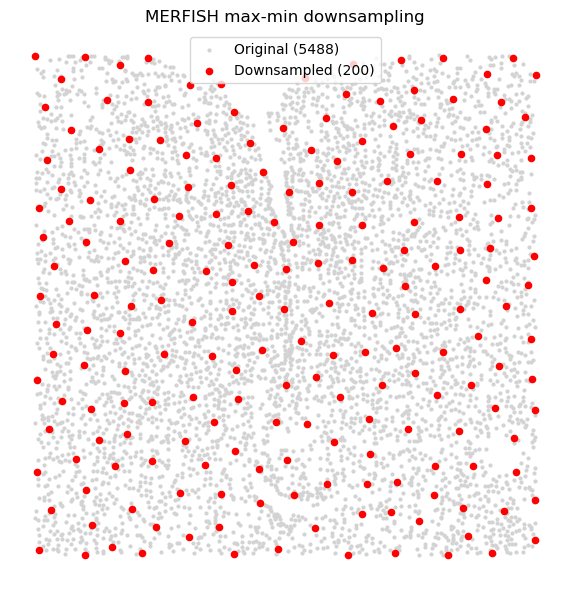

In [3]:
downsampled_sliceA,indices_dsa = _downsample.maxmin_downsample_slice_merfish(sliceA, 200)
_downsample.visualize_merfish_downsampled_points(sliceA, downsampled_sliceA)

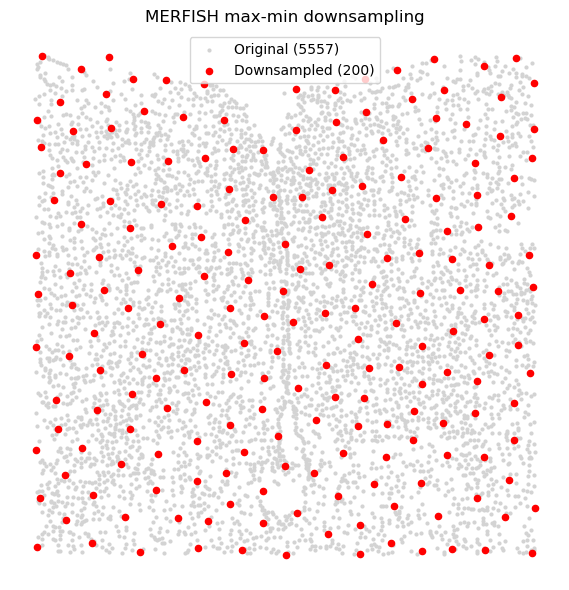

In [4]:
downsampled_sliceB,indices_dsb = _downsample.maxmin_downsample_slice_merfish(sliceB, 200)
_downsample.visualize_merfish_downsampled_points(sliceB, downsampled_sliceB)

In [5]:
# reproducible cost matrix
PT_PATH = f"./results/gene_cost_matrix/{pair[0]}_{pair[1]}_somde_cost_matrix.pt"

CSV_PATH = (f"./results/align_data/{pair[0]}_{pair[1]}_cost_matrix.csv"
)

C = torch.load(PT_PATH, map_location="cpu")
df = pd.DataFrame(C.numpy())
df.to_csv(CSV_PATH, index=False, header=False)

M = _fsgw_utils.extract_feature_matrix(CSV_PATH, indices_dsa, indices_dsb)

After rescaling: min = 0.05077289827208063, max = 1.0.


In [6]:
D_A_test = distance.cdist(downsampled_sliceA.obsm['spatial'], downsampled_sliceA.obsm['spatial'])
D_B_test = distance.cdist(downsampled_sliceB.obsm['spatial'], downsampled_sliceB.obsm['spatial'])
testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
print(np.min(testA), np.min(testB))

98.50759140234227 97.67900930377812


In [7]:

cutoff_GW_list = {100}
cutoff_CC_list = {0.2}

SAVE_DIR = Path("./results/align_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

test_label_sub = np.concatenate((np.array(downsampled_sliceA.obs['original_clusters']),np.array(downsampled_sliceB.obs['original_clusters'])),axis=0)
XA_sub = downsampled_sliceA.obsm['spatial']
XB_sub = downsampled_sliceB.obsm['spatial']


for cutoff_GW in tqdm(cutoff_GW_list, desc="Running different GW cutoffs for downsampled {pair}"):
    for cutoff_CC in cutoff_CC_list:
        print(f"\nRunning GW cutoff = {cutoff_GW}, CC cutoff = {cutoff_CC}")

        P = _fsgw_utils.fsgw_mvc_exp(
            D_A_test,
            D_B_test,
            M,
            gw_cutoff=cutoff_GW,
            w_cutoff=cutoff_CC,
        )

        print("P.sum():", P.sum())

        save_path = (
            SAVE_DIR
            / f"ds_matching_{pair}_{cutoff_GW}_{cutoff_CC}.npy"
        )

        np.save(save_path, P)
        print(f"Saved to: {save_path}")

Running different GW cutoffs for downsampled {pair}:   0%|          | 0/1 [00:00<?, ?it/s]


Running GW cutoff = 100, CC cutoff = 0.2


sOT Iterations: 100%|██████████| 10000/10000 [00:02<00:00, 3660.99it/s]
Running different GW cutoffs for downsampled {pair}: 100%|██████████| 1/1 [06:10<00:00, 370.63s/it]

P.sum(): 0.35499999999998433
Saved to: results/align_data/ds_matching_['-0.04', '-0.09']_100_0.2.npy
